In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Load dataset
df = pd.read_csv('car_prices.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()


Dataset shape: (558837, 16)

Columns: ['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state', 'condition', 'odometer', 'color', 'interior', 'seller', 'mmr', 'sellingprice', 'saledate']

First few rows:


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [ ]:
# Data Preparation for K-means
print("Step 1: Data Preparation for K-means\n")

# Remove irrelevant columns
df_clean = df.drop(['vin', 'saledate'], axis=1)

# Remove rows with missing sellingprice (target variable)
df_clean = df_clean.dropna(subset=['sellingprice'])

# Select only numeric features for K-means
numeric_features = ['year', 'condition', 'odometer', 'mmr', 'sellingprice']
df_numeric = df_clean[numeric_features].copy()

# Fill remaining missing values with median
df_numeric = df_numeric.fillna(df_numeric.median())

print(f"Clean dataset shape: {df_numeric.shape}")
print(f"\nMissing values: {df_numeric.isnull().sum().sum()}")
print(f"\nFeatures for clustering: {numeric_features}")
print(f"\nDescriptive statistics:")
df_numeric.describe()


Step 1: Data Preparation for K-means

Clean dataset shape: (558825, 5)

Missing values: 0

Features for clustering: ['year', 'condition', 'odometer', 'mmr', 'sellingprice']

Descriptive statistics:


,year,condition,odometer,mmr,sellingprice
count,558825.000000,558825.000000,558825.000000,558825.000000,558825.000000
mean,2010.038864,30.764089,68317.949882,13769.306804,13611.358810
std,3.966882,13.274980,53394.838745,9679.747532,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,24.000000,28375.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52255.000000,12250.000000,12100.000000
75%,2013.000000,41.000000,99104.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


In [ ]:
# Scale the data (CRITICAL for K-means)
print("Step 2: Feature Scaling\n")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

print(f"Scaled data shape: {X_scaled.shape}")
print(f"Mean of scaled features: {X_scaled.mean(axis=0)}")
print(f"Std of scaled features: {X_scaled.std(axis=0)}")
print("\nScaling ensures all features contribute equally to clustering")


Step 2: Feature Scaling

Scaled data shape: (558825, 5)
Mean of scaled features: [ 1.24262618e-14 -1.93267116e-18 -1.23945253e-16 -9.98885829e-17
 -6.68297342e-17]
Std of scaled features: [1. 1. 1. 1. 1.]

Scaling ensures all features contribute equally to clustering
Scaled data shape: (558825, 5)
Mean of scaled features: [ 1.24262618e-14 -1.93267116e-18 -1.23945253e-16 -9.98885829e-17
 -6.68297342e-17]
Std of scaled features: [1. 1. 1. 1. 1.]

Scaling ensures all features contribute equally to clustering


Step 3: Find Optimal K using Elbow Method



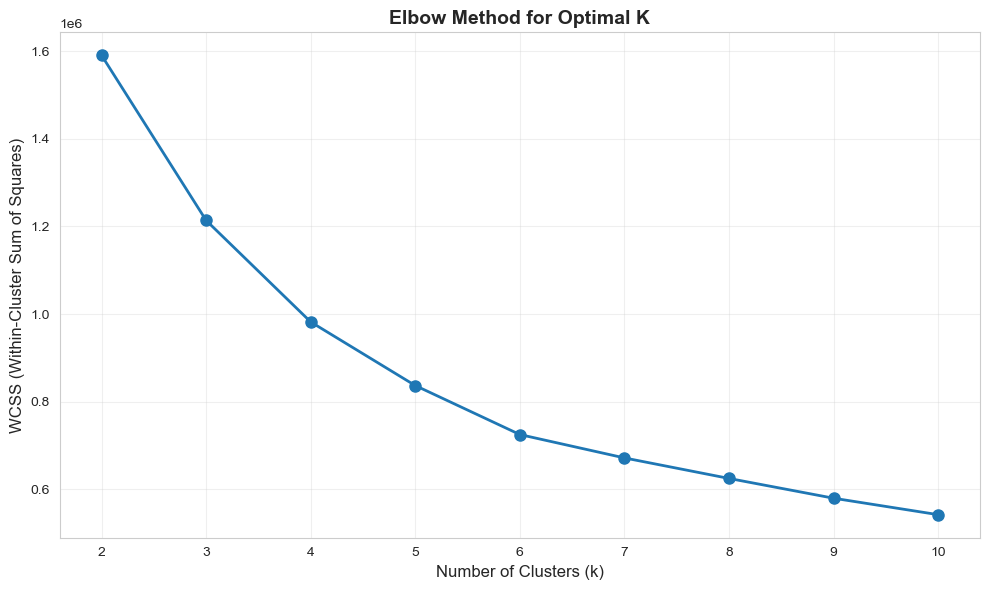

Based on elbow curve, optimal k appears to be around 3-4


In [ ]:
# Determine optimal number of clusters using Elbow Method
print("Step 3: Find Optimal K using Elbow Method\n")

wcss = []
K_range = range(2, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    wcss.append(kmeans_temp.inertia_)

# Plot Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Based on elbow curve, optimal k appears to be around 3-4")


In [ ]:
# Train K-means with optimal k=3
print("Step 4: Train K-means Model (k=3)\n")

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataframe
df_numeric['cluster'] = clusters

print(f"Clustering completed!")
print(f"Cluster distribution:")
print(df_numeric['cluster'].value_counts().sort_index())
print(f"\nCluster centers (scaled):")
print(kmeans.cluster_centers_)


Step 4: Train K-means Model (k=3)

Clustering completed!
Cluster distribution:
cluster
0    171148
1     93741
2    293936
Name: count, dtype: int64

Cluster centers (scaled):
[[-1.23319982 -0.55191878  1.15850001 -0.90623916 -0.90440257]
 [ 0.68079494  0.49849645 -0.72586678  1.63412769  1.63879417]
 [ 0.50137355  0.16259355 -0.44348286  0.00691459  0.00435668]]
Clustering completed!
Cluster distribution:
cluster
0    171148
1     93741
2    293936
Name: count, dtype: int64

Cluster centers (scaled):
[[-1.23319982 -0.55191878  1.15850001 -0.90623916 -0.90440257]
 [ 0.68079494  0.49849645 -0.72586678  1.63412769  1.63879417]
 [ 0.50137355  0.16259355 -0.44348286  0.00691459  0.00435668]]


Step 5: Analyze Factors Affecting Car Price

Average values by cluster:
                year  condition       odometer           mmr  sellingprice
cluster                                                                   
0        2005.145278  23.439643  130196.860624   4994.910545   4791.795376
1        2012.739975  37.423443   29552.414045  29580.669078  29583.294354
2        2012.026788  32.905064   44651.125401  13835.809241  13652.950969


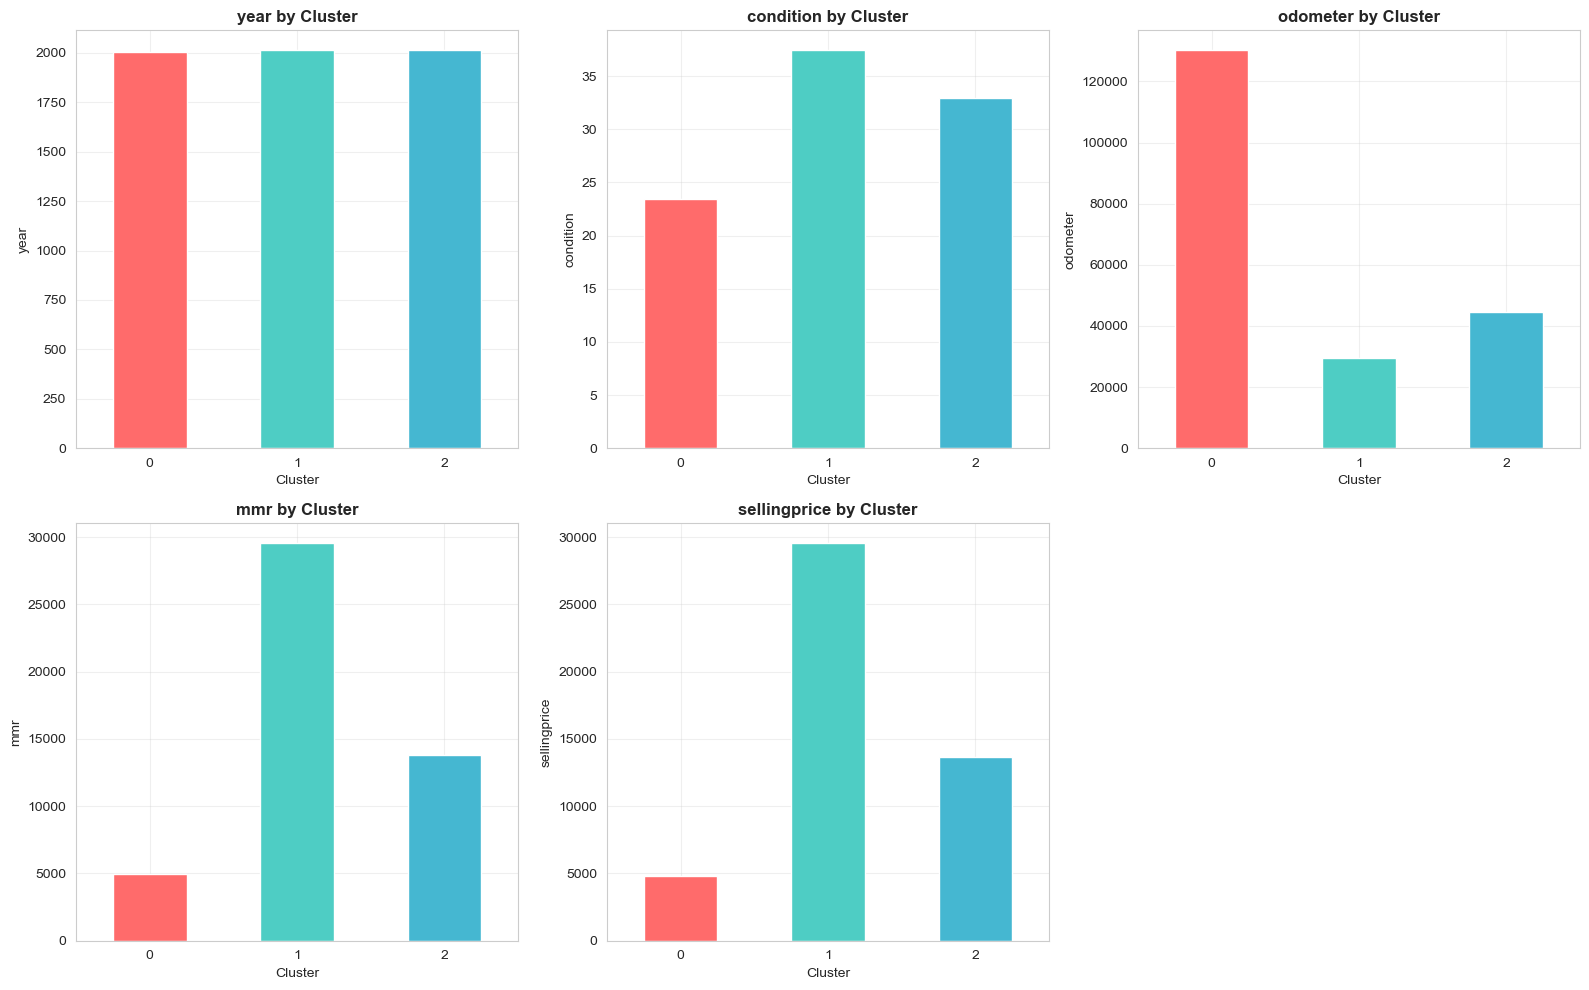

In [ ]:
# Analyze cluster characteristics
print("Step 5: Analyze Factors Affecting Car Price\n")

# Calculate mean values for each cluster
cluster_summary = df_numeric.groupby('cluster').mean()
print("Average values by cluster:")
print(cluster_summary)

# Visualize cluster profiles
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features_to_plot = ['year', 'condition', 'odometer', 'mmr', 'sellingprice']

for idx, feature in enumerate(features_to_plot):
    row = idx // 3
    col = idx % 3
    cluster_summary[feature].plot(kind='bar', ax=axes[row, col], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    axes[row, col].set_title(f'{feature} by Cluster', fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel('Cluster')
    axes[row, col].set_ylabel(feature)
    axes[row, col].grid(True, alpha=0.3)
    axes[row, col].tick_params(axis='x', rotation=0)  # Xoay label về chiều dọc

# Remove empty subplot
axes[1, 2].remove()

plt.tight_layout()
plt.show()


Step 6: Identify Top 3 Factors Affecting Price

Correlation with Selling Price:
year         0.586480
condition    0.313121
odometer    -0.582271
mmr          0.983634
Name: sellingprice, dtype: float64

TOP 3 FACTORS AFFECTING CAR PRICE:
1. MMR: correlation = 0.9836
2. YEAR: correlation = 0.5865
3. ODOMETER: correlation = -0.5823

These 3 features will be used for 3D visualization


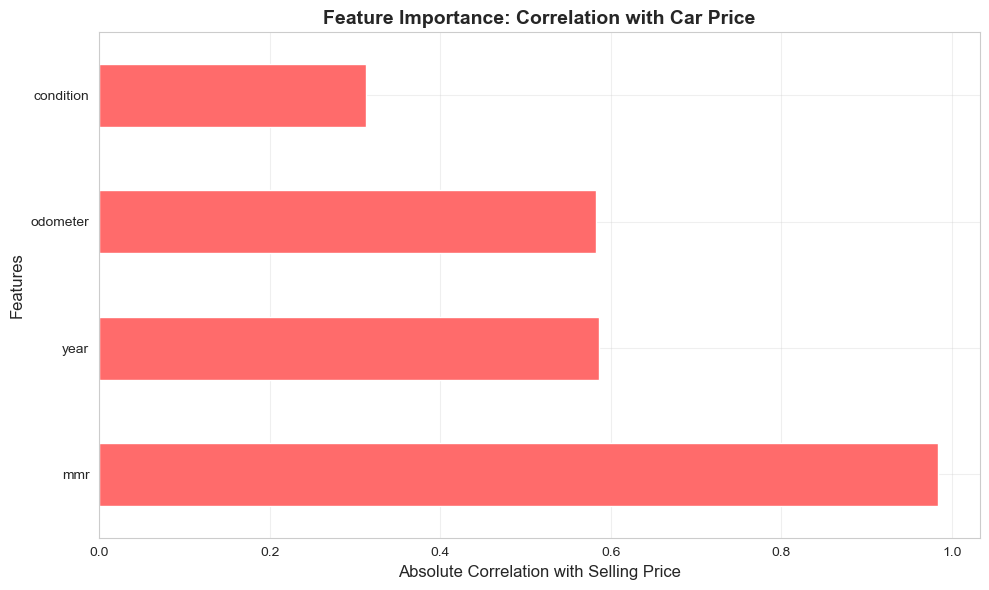

In [ ]:
# Identify top 3 factors influencing price
print("Step 6: Identify Top 3 Factors Affecting Price\n")

# Calculate correlation with selling price
correlations = df_numeric.drop('cluster', axis=1).corr()['sellingprice'].drop('sellingprice')
correlations_abs = correlations.abs().sort_values(ascending=False)

print("Correlation with Selling Price:")
print(correlations)
print("\n" + "="*50)
print("TOP 3 FACTORS AFFECTING CAR PRICE:")
print("="*50)

top_3_features = correlations_abs.head(3).index.tolist()
for i, feature in enumerate(top_3_features, 1):
    corr_value = correlations[feature]
    print(f"{i}. {feature.upper()}: correlation = {corr_value:.4f}")

print("\nThese 3 features will be used for 3D visualization")

# Visualize correlations
plt.figure(figsize=(10, 6))
correlations_abs.plot(kind='barh', color='#FF6B6B')
plt.xlabel('Absolute Correlation with Selling Price', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Importance: Correlation with Car Price', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Create Interactive 3D Scatter Plot with Top 3 Features
print("Step 7: Interactive 3D Visualization\n")

# Sample data for better performance (if dataset is too large)
sample_size = min(10000, len(df_numeric))
df_sample = df_numeric.sample(n=sample_size, random_state=42)

# Create 3D scatter plot
fig = px.scatter_3d(
    df_sample,
    x=top_3_features[0],
    y=top_3_features[1],
    z=top_3_features[2],
    color='cluster',
    color_continuous_scale=['#FF6B6B', '#4ECDC4', '#45B7D1'],
    title=f'3D Cluster Visualization: Top 3 Price Factors',
    labels={
        top_3_features[0]: top_3_features[0].upper(),
        top_3_features[1]: top_3_features[1].upper(),
        top_3_features[2]: top_3_features[2].upper(),
        'cluster': 'Cluster'
    },
    opacity=0.7,
    size_max=5
)

# Update layout for better interactivity
fig.update_layout(
    width=900,
    height=700,
    scene=dict(
        xaxis_title=top_3_features[0].upper(),
        yaxis_title=top_3_features[1].upper(),
        zaxis_title=top_3_features[2].upper(),
    ),
    font=dict(size=12)
)

fig.show()

print(f"\nVisualization shows {sample_size} samples")
print(f"Features: {top_3_features[0]}, {top_3_features[1]}, {top_3_features[2]}")
print("You can rotate, zoom, and interact with the plot!")


Step 7: Interactive 3D Visualization




Visualization shows 10000 samples
Features: mmr, year, odometer
You can rotate, zoom, and interact with the plot!


In [ ]:
# Additional 3D visualization with cluster centers
print("Step 8: 3D Plot with Cluster Centers\n")

# Get cluster centers in original scale
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(cluster_centers_original, columns=numeric_features)

# Create scatter plot with cluster centers
fig = go.Figure()

# Add scatter points for each cluster
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for cluster_id in range(3):
    cluster_data = df_sample[df_sample['cluster'] == cluster_id]
    fig.add_trace(go.Scatter3d(
        x=cluster_data[top_3_features[0]],
        y=cluster_data[top_3_features[1]],
        z=cluster_data[top_3_features[2]],
        mode='markers',
        name=f'Cluster {cluster_id}',
        marker=dict(size=3, color=colors[cluster_id], opacity=0.6)
    ))

# Add cluster centers
fig.add_trace(go.Scatter3d(
    x=centers_df[top_3_features[0]],
    y=centers_df[top_3_features[1]],
    z=centers_df[top_3_features[2]],
    mode='markers',
    name='Cluster Centers',
    marker=dict(size=15, color='black', symbol='diamond', line=dict(color='yellow', width=2))
))

fig.update_layout(
    title='3D Cluster Visualization with Centroids',
    scene=dict(
        xaxis_title=top_3_features[0].upper(),
        yaxis_title=top_3_features[1].upper(),
        zaxis_title=top_3_features[2].upper(),
    ),
    width=900,
    height=700
)

fig.show()

print("\nCluster Centers (Original Scale):")
print(centers_df)


Step 8: 3D Plot with Cluster Centers




Cluster Centers (Original Scale):
          year  condition       odometer           mmr  sellingprice
0  2005.146910  23.437385  130175.815997   4997.148406   4793.892332
1  2012.739494  37.381613   29560.444915  29587.236154  29588.770900
2  2012.027751  32.922513   44638.275013  13836.238197  13653.834264


## K-means Clustering Insights: Car Price Analysis

In [ ]:
# K-means Clustering Insights
print("="*70)
print("KEY INSIGHTS FROM K-MEANS CLUSTERING ANALYSIS")
print("="*70)

print("\n1. ALGORITHM OVERVIEW")
print("   - K-means groups similar cars into 3 distinct market segments")
print("   - Each cluster represents cars with similar pricing characteristics")
print("   - Unsupervised learning reveals natural price patterns in data")

print("\n2. TOP 3 FACTORS AFFECTING CAR PRICE")
for i, feature in enumerate(top_3_features, 1):
    corr_value = correlations[feature]
    impact = "Strong positive" if corr_value > 0.5 else "Strong negative" if corr_value < -0.5 else "Moderate"
    print(f"   {i}. {feature.upper()}: {impact} impact (r={corr_value:.3f})")

print("\n3. CLUSTER CHARACTERISTICS")
for cluster_id in range(3):
    cluster_data = df_numeric[df_numeric['cluster'] == cluster_id]
    avg_price = cluster_data['sellingprice'].mean()
    avg_year = cluster_data['year'].mean()
    avg_odometer = cluster_data['odometer'].mean()
    size = len(cluster_data)

    if avg_price < df_numeric['sellingprice'].quantile(0.33):
        segment = "BUDGET"
    elif avg_price < df_numeric['sellingprice'].quantile(0.67):
        segment = "MID-RANGE"
    else:
        segment = "PREMIUM"

    print(f"\n   Cluster {cluster_id} - {segment} SEGMENT ({size:,} cars)")
    print(f"      Average Price: ${avg_price:,.0f}")
    print(f"      Average Year: {avg_year:.0f}")
    print(f"      Average Mileage: {avg_odometer:,.0f} miles")

print("\n4. BUSINESS INSIGHTS")
print("   - Price segmentation helps dealers optimize inventory")
print("   - Buyers can identify best value within their target cluster")
print("   - Top 3 factors provide focused negotiation points")
print("   - Clusters reveal market preferences and trends")

print("\n5. K-MEANS ADVANTAGES FOR PRICING")
print("   - Identifies natural price groups without predefined categories")
print("   - Reveals hidden patterns in multi-dimensional data")
print("   - Scalable to large datasets efficiently")
print("   - Provides interpretable market segments")

print("\n6. LIMITATIONS & CONSIDERATIONS")
print("   - Assumes spherical clusters (may miss complex patterns)")
print("   - Sensitive to feature scaling (we addressed with StandardScaler)")
print("   - Requires predefined k (we used Elbow method)")
print("   - Only uses numeric features (excluded categorical data)")

print("\n" + "="*70)
print("RECOMMENDATION: Focus on top 3 factors when pricing or buying cars")
print("="*70)


KEY INSIGHTS FROM K-MEANS CLUSTERING ANALYSIS

1. ALGORITHM OVERVIEW
   - K-means groups similar cars into 3 distinct market segments
   - Each cluster represents cars with similar pricing characteristics
   - Unsupervised learning reveals natural price patterns in data

2. TOP 3 FACTORS AFFECTING CAR PRICE
   1. MMR: Strong positive impact (r=0.984)
   2. YEAR: Strong positive impact (r=0.586)
   3. ODOMETER: Strong negative impact (r=-0.582)

3. CLUSTER CHARACTERISTICS

   Cluster 0 - BUDGET SEGMENT (171,148 cars)
      Average Price: $4,792
      Average Year: 2005
      Average Mileage: 130,197 miles

   Cluster 1 - PREMIUM SEGMENT (93,741 cars)
      Average Price: $29,583
      Average Year: 2013
      Average Mileage: 29,552 miles

   Cluster 2 - MID-RANGE SEGMENT (293,936 cars)
      Average Price: $13,653
      Average Year: 2012
      Average Mileage: 44,651 miles

4. BUSINESS INSIGHTS
   - Price segmentation helps dealers optimize inventory
   - Buyers can identify best valu

Step 9: Price Distribution Across Clusters



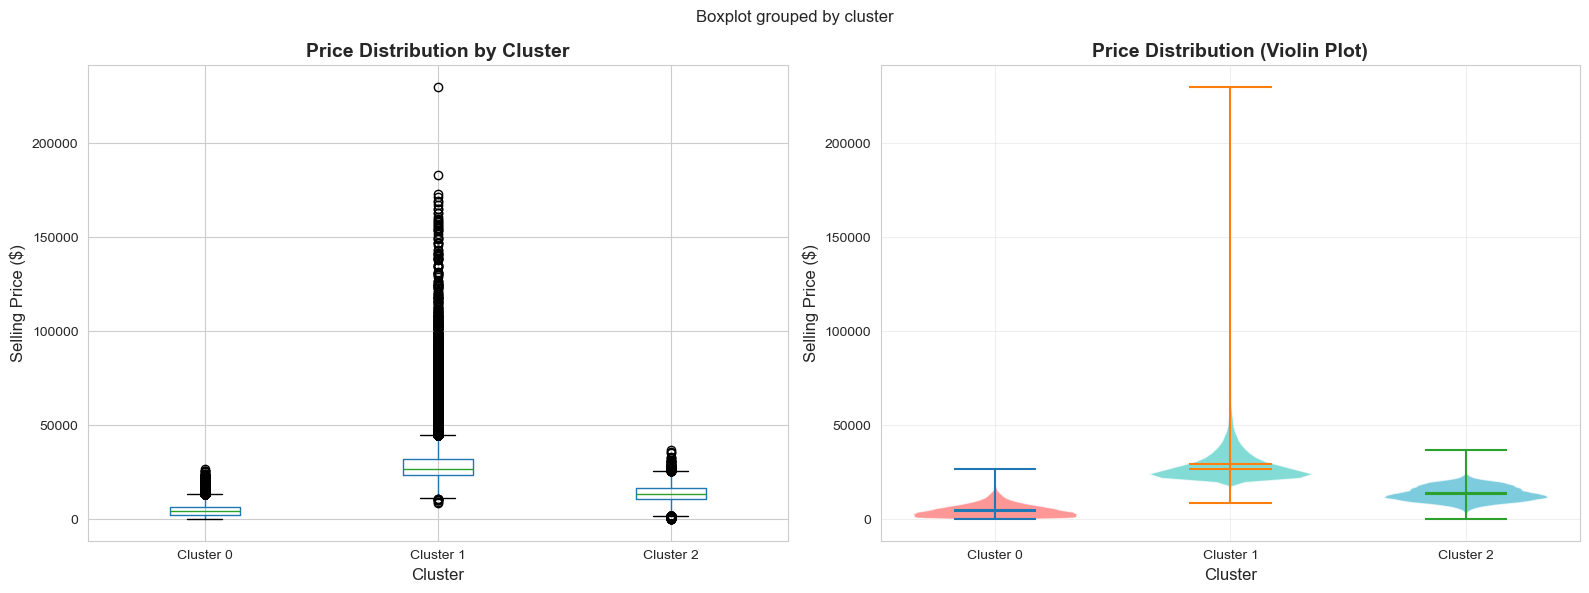


Price statistics by cluster:
            count          mean          std     min      25%      50%  \
cluster                                                                  
0        171148.0   4791.795376  3349.552464     1.0   2200.0   4100.0   
1         93741.0  29583.294354  9939.937420  8500.0  23600.0  26800.0   
2        293936.0  13652.950969  4002.597614     1.0  10700.0  13300.0   

             75%       max  
cluster                     
0         6700.0   26800.0  
1        32001.0  230000.0  
2        16600.0   37000.0  


In [ ]:
# Comparative Analysis: Cluster Price Distribution
print("Step 9: Price Distribution Across Clusters\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
df_numeric.boxplot(column='sellingprice', by='cluster', ax=axes[0])
axes[0].set_title('Price Distribution by Cluster', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('Selling Price ($)', fontsize=12)
plt.sca(axes[0])
plt.xticks([1, 2, 3], ['Cluster 0', 'Cluster 1', 'Cluster 2'])

# Violin plot
for cluster_id in range(3):
    cluster_data = df_numeric[df_numeric['cluster'] == cluster_id]
    parts = axes[1].violinplot(
        [cluster_data['sellingprice'].values],
        positions=[cluster_id],
        widths=0.7,
        showmeans=True,
        showmedians=True
    )
    for pc in parts['bodies']:
        pc.set_facecolor(['#FF6B6B', '#4ECDC4', '#45B7D1'][cluster_id])
        pc.set_alpha(0.7)

axes[1].set_title('Price Distribution (Violin Plot)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Selling Price ($)', fontsize=12)
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['Cluster 0', 'Cluster 1', 'Cluster 2'])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPrice statistics by cluster:")
print(df_numeric.groupby('cluster')['sellingprice'].describe())
